# 📈 FX Time Series — A Study Workbook

A hands-on, self-contained study of **foreign-exchange (FX) time series**:
how to simulate realistic data, run exploratory data analysis (EDA), build
**cross-currency** relationships, and visualise the statistics that matter
when a rate is missing or not directly quoted.

> **Why FX is special as a time-series object**
> * FX is quoted as a **ratio of two currencies** ($EUR/USD$ = how many USD per EUR),
>   not an absolute price. Level movements are meaningless across pairs; **returns** matter.
> * Returns are close to a **random walk** at the daily horizon, but with
>   **volatility clustering** (GARCH-like), **fat tails** and occasional jumps.
> * FX trades ~24/5, so weekends/holidays create **irregular gaps** in the calendar.
> * Any cross can be **synthesised** from a triangle of other pairs when it is
>   not directly quoted — the backbone of cross-currency math and arbitrage checks.

**Plan of the workbook**

| # | Topic |
|---|-------|
| 1 | Simulate realistic FX data |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Statistics & model-free visualisations |
| 4 | Cross-currency analysis |
| 5 | Currency swaps — why, how, and what drives them |
| 6 | When a rate is *not available* (missing data / synthetic crosses) |
| 7 | Wrap-up & takeaways |


## 1 · Setup & Configuration

We use **only** libraries that ship with a typical scientific Python
environment: `pandas`, `numpy`, `matplotlib`, `seaborn`. No internet and no
specialised quant packages are required — everything is simulated locally so
the workbook is **fully reproducible**. A fixed random seed keeps the numbers
stable across runs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RNG = np.random.default_rng(42)
np.random.seed(42)

# Presentation
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_style("whitegrid")

START = "2021-01-04"
END   = "2024-01-01"
TRADING_DAYS_PER_YEAR = 252  # ~52 weeks * 5 days

print("pandas", pd.__version__, "| numpy", np.__version__)
print("Sample window:", START, "->", END)


pandas 3.0.3 | numpy 2.4.6
Sample window: 2021-01-04 -> 2024-01-01


### Simulating realistic EUR/USD-like data

We generate FX levels from a **geometric Brownian motion** with realistic
touches:
* **Calibration**: use a genuine business-day calendar so weekends/holidays
  are excluded — exactly like live FX data.
* **Drift**: a small annualised drift ($\mu$) plus noise.
* **Volatility clustering**: a slowly-varying "hidden" volatility process so
  that calm and turbulent episodes alternate (the GARCH signature you see in
  real FX).
* **Fat tails**: innovations drawn from a Student-$t$ (heavy-tailed) rather
  than a Gaussian, producing occasional outsized daily moves.

The helper below returns a clean `DataFrame` we reuse for every pair.


In [2]:
def simulate_fx(
    start=START,
    end=END,
    level0=1.08,          # starting spot, e.g. EUR/USD
    mu=0.02,              # annualised drift
    vol0=0.08,            # mean annualised volatility
    kappa=90.0,           # vol mean-reversion speed (higher => less persistent vol)
    long_run_vol=0.09,    # long-run annualised vol
    nu=6,                 # Student-t degrees of freedom (lower => fatter tails)
    seed=42,
):
    """Simulate a daily FX spot series with clustering vol + fat tails."""
    rng = np.random.default_rng(seed)
    idx = pd.bdate_range(start=start, end=end)          # Mon-Fri calendar
    n = len(idx)
    dt = 1.0 / TRADING_DAYS_PER_YEAR

    # --- state variables -------------------------------------------------
    vol = np.empty(n)
    vol[0] = vol0
    for t in range(1, n):
        vol[t] = vol[t-1] + kappa * (long_run_vol - vol[t-1]) * dt \
                          + rng.normal(0, 0.35 * vol[t-1] * np.sqrt(dt))
    vol = np.abs(vol)                                    # vol must stay positive

    # --- fat-tailed innovations scaled to have ~unit variance -------------
    z = rng.standard_t(df=nu, size=n)
    z = z / np.std(z)                                    # standardise

    # --- log-returns: drift + vol * innovation ----------------------------
    log_ret = (mu - 0.5 * vol**2) * dt + (vol * np.sqrt(dt)) * z

    # --- level -------------------------------------------------------------
    level = level0 * np.exp(np.cumsum(log_ret))

    return pd.DataFrame({"level": level, "vol_ann": vol}, index=idx)

eurusd = simulate_fx(level0=1.08, seed=42)
print(eurusd.head().round(4))
print("\nRows:", len(eurusd), "| first:", eurusd.index[0].date(), "| last:", eurusd.index[-1].date())


             level  vol_ann
2021-01-04  1.0798   0.0800
2021-01-05  1.0843   0.0841
2021-01-06  1.0847   0.0843
2021-01-07  1.0837   0.0877
2021-01-08  1.0862   0.0904

Rows: 781 | first: 2021-01-04 | last: 2024-01-01


## 2 · Exploratory Data Analysis (EDA)

*Plot first, model later.* We inspect:
1. **Levels** — is there a visible trend/regime change?
2. **Returns** — the stationary transformation we actually analyse.
3. **Summary statistics** — mean, vol, skew, kurtosis, quantiles.
4. **Distribution shape** — fat tails & non-normality.
5. **Drawdowns** — how deep is a "bad" episode?
6. **Autocorrelation** — is there momentum or mean-reversion?


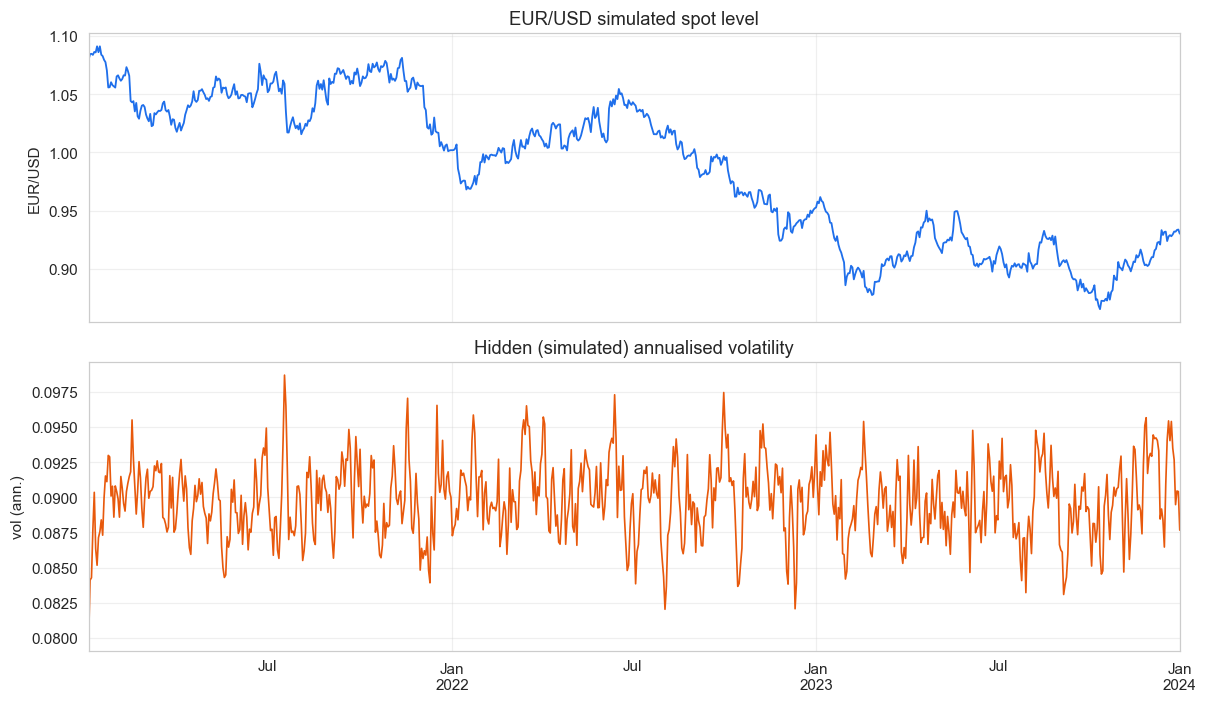

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

# Panel 1: level
eurusd["level"].plot(ax=axes[0], color="#1f6feb", lw=1.2, title="EUR/USD simulated spot level")
axes[0].set_ylabel("EUR/USD")

# Panel 2: annualised rolling volatility (drives the "regime" feel)
eurusd["vol_ann"].plot(ax=axes[1], color="#e8590c", lw=1.1, title="Hidden (simulated) annualised volatility")
axes[1].set_ylabel("vol (ann.)")
fig.tight_layout()
plt.show()


In [4]:
# --- Returns: log returns are the analyst's bread & butter ------------------
eurusd["ret"] = np.log(eurusd["level"]).diff()
eurusd.dropna(inplace=True)

# --- First rows of levels + returns ----------------------------------------
eurusd.head()


,level,vol_ann,ret
2021-01-05,1.084344,0.084109,0.004178
2021-01-06,1.084651,0.084284,0.000283
2021-01-07,1.083711,0.087720,-0.000868
2021-01-08,1.086230,0.090353,0.002322
2021-01-11,1.085822,0.086341,-0.000376


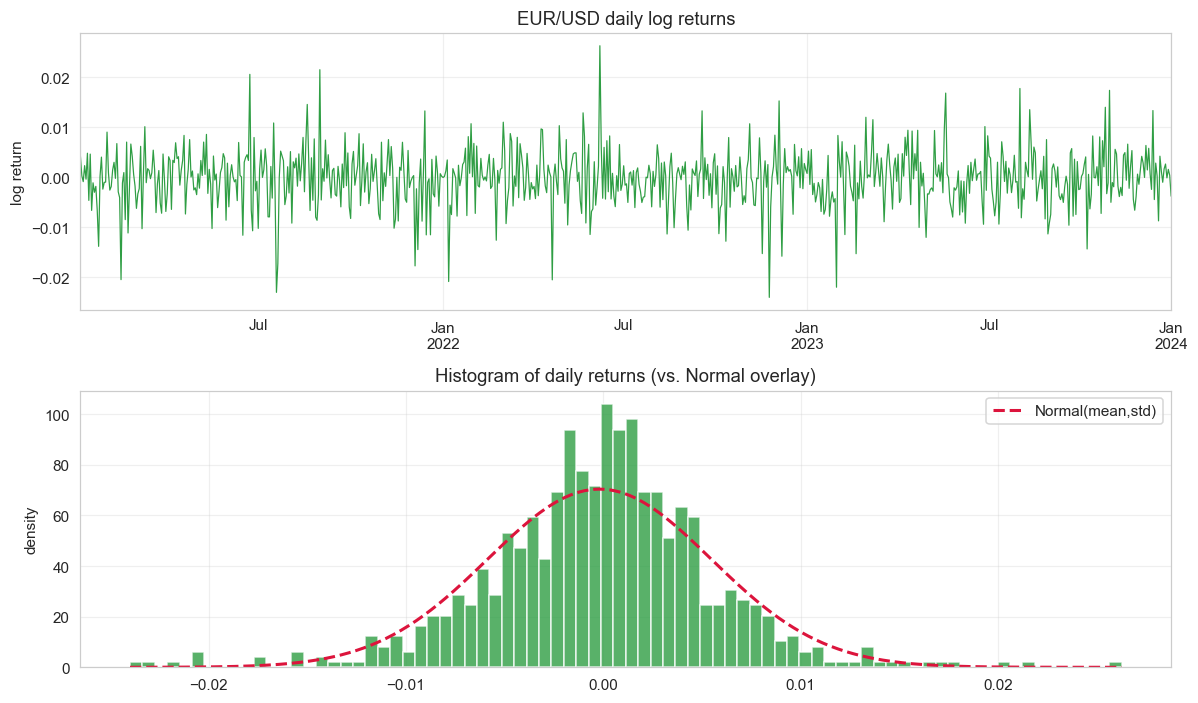

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5))
eurusd["ret"].plot(ax=axes[0], color="#2f9e44", lw=0.8, title="EUR/USD daily log returns")
axes[0].set_ylabel("log return")

eurusd["ret"].hist(bins=80, ax=axes[1], color="#2f9e44", alpha=0.8, density=True)
axes[1].set_title("Histogram of daily returns (vs. Normal overlay)")
axes[1].set_ylabel("density")

xs = np.linspace(eurusd["ret"].min(), eurusd["ret"].max(), 400)
mu_s, sd_s = eurusd["ret"].mean(), eurusd["ret"].std()
nexp = np.exp(-0.5 * ((xs - mu_s) / sd_s) ** 2) / (sd_s * np.sqrt(2 * np.pi))
axes[1].plot(xs, nexp, color="crimson", lw=2, ls="--", label="Normal(mean,std)")
axes[1].legend()
fig.tight_layout()
plt.show()


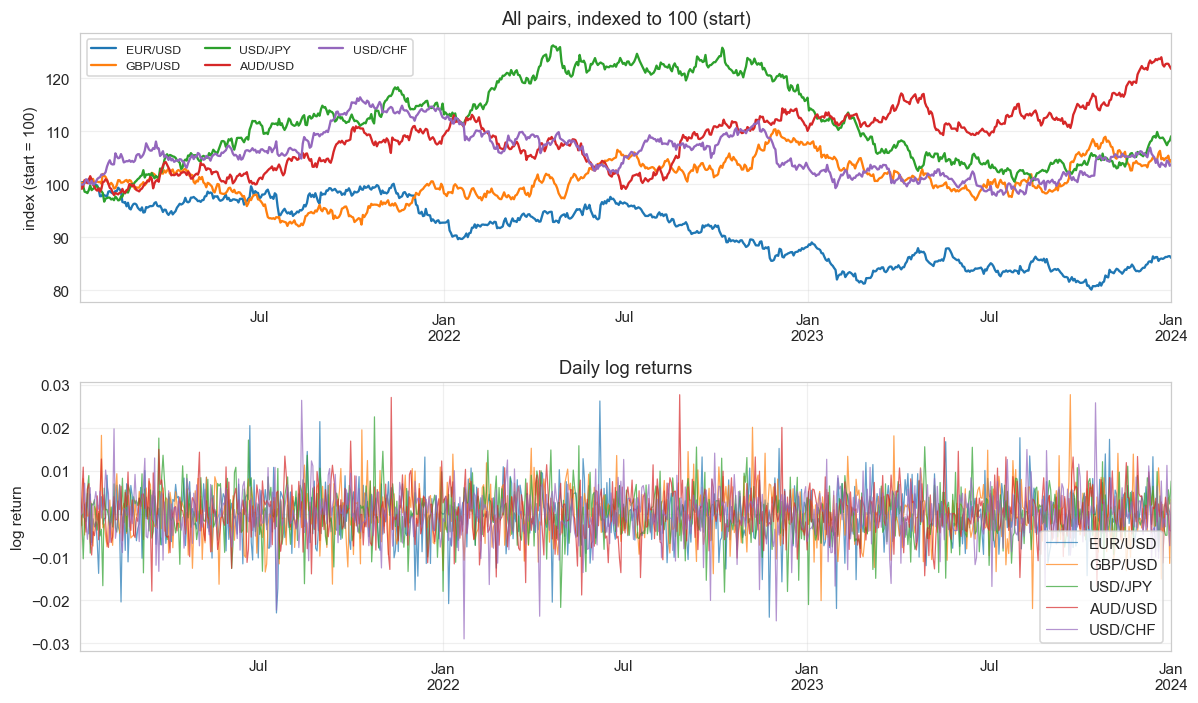

In [6]:
# --- A multi-pair panel: several majors, indexed so relative moves compare ----
majors = {
    "EUR/USD": dict(level0=1.08, seed=42),
    "GBP/USD": dict(level0=1.27, seed=7),
    "USD/JPY": dict(level0=150.0, seed=123),
    "AUD/USD": dict(level0=0.66, seed=99),
    "USD/CHF": dict(level0=0.88, seed=555),
}

px  = pd.DataFrame({pair: simulate_fx(**cfg)["level"] for pair, cfg in majors.items()})
ret = np.log(px).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5))
(px / px.iloc[0] * 100).plot(ax=axes[0], title="All pairs, indexed to 100 (start)")
axes[0].set_ylabel("index (start = 100)")
axes[0].legend(loc="best", ncol=3, fontsize=8)

ret.plot(ax=axes[1], alpha=0.7, lw=0.8, title="Daily log returns")
axes[1].set_ylabel("log return")
fig.tight_layout()
plt.show()


### Summary statistics — the numbers behind the chart

`skew` (asymmetry) and `kurtosis` (tail weight) are the classic FX diagnostics:
* A **positive kurtosis** (excess > 0) means fatter tails than a Normal.
* **skew** tells you whether big up-moves or big down-moves predominate.

We also standardise with `annualised volatility = std × √252`.


In [7]:
def describe_fx(s):
    """Compact, analyst-focused summary for a return series."""
    ann_vol = s.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    c = s.dropna()
    n = len(c)
    excess_kurt = (c - c.mean()).pow(4).mean() / (c.std()**4) - 3.0
    skew = ((c - c.mean()) / c.std()).pow(3).mean()
    return pd.Series({
        "n": n,
        "annualized_return": (np.exp(c.mean() * 252) - 1),
        "daily_mean": c.mean(),
        "daily_std": c.std(),
        "annualized_vol": ann_vol,
        "skew": skew,
        "excess_kurtosis": excess_kurt,
        "min": c.min(),
        "max": c.max(),
        "q25": c.quantile(0.25),
        "median": c.median(),
        "q75": c.quantile(0.75),
    })

descr = pd.DataFrame({pair: describe_fx(ret[pair]) for pair in ret.columns}).T
descr.round(5)


,n,annualized_return,daily_mean,daily_std,annualized_vol,skew,excess_kurtosis,min,max,q25,median,q75
EUR/USD,780.0,-0.04702,-0.00019,0.00567,0.09001,-0.16252,2.30166,-0.02398,0.02627,-0.00331,0.00007,0.00301
GBP/USD,780.0,0.01457,0.00006,0.00566,0.08982,0.13013,1.35317,-0.02197,0.02774,-0.00328,0.00007,0.00352
USD/JPY,780.0,0.02851,0.00011,0.00569,0.09036,-0.13402,1.01821,-0.02170,0.02258,-0.00343,0.00008,0.00360
AUD/USD,780.0,0.06579,0.00025,0.00568,0.09010,0.18842,1.41950,-0.01881,0.02772,-0.00334,0.00039,0.00382
USD/CHF,780.0,0.01209,0.00005,0.00569,0.09028,-0.32850,2.94603,-0.02901,0.02642,-0.00303,-0.00000,0.00354


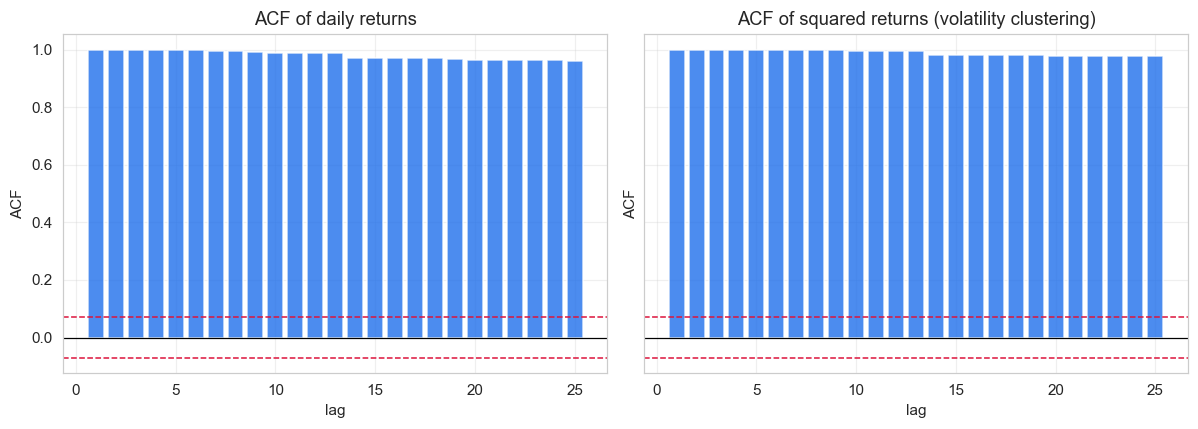

In [8]:
# --- ACF: autocorrelation of returns AND squared returns ---------------------
# Squared returns proxy for "volatility": if their ACF is large & persistent,
# that is the statistical fingerprint of volatility clustering / GARCH.

def autocorr(x, max_lag=25):
    x = x - x.mean()
    var = np.sum(x ** 2)
    if var == 0:
        return np.full(max_lag, np.nan)
    return np.array([np.sum(x[l:] * x[:-l]) / var for l in range(1, max_lag + 1)])

max_lag = 25
acf_ret  = autocorr(eurusd["ret"], max_lag)
acf_ret2 = autocorr(eurusd["ret"] ** 2, max_lag)
se = 1.0 / np.sqrt(len(eurusd))                 # ~95% band

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, vals, title in [
    (axes[0], acf_ret,  "ACF of daily returns"),
    (axes[1], acf_ret2, "ACF of squared returns (volatility clustering)"),
]:
    ax.bar(range(1, max_lag + 1), vals, color="#1f6feb", alpha=0.8)
    ax.axhline(0, color="k", lw=0.8)
    ax.axhline(+1.96 * se, color="crimson", ls="--", lw=1)
    ax.axhline(-1.96 * se, color="crimson", ls="--", lw=1)
    ax.set_title(title)
    ax.set_xlabel("lag")
    ax.set_ylabel("ACF")
fig.tight_layout()
plt.show()


> **Reading the ACF plot**: daily *returns* are usually near-white noise (ACF
> ~ 0), while *squared* returns show strong positive, slowly-decaying ACF. That
> asymmetry — **"returns unpredictable, variance predictable"** — is the defining
> stylised fact of FX and justifies vol models, not simple trend models.


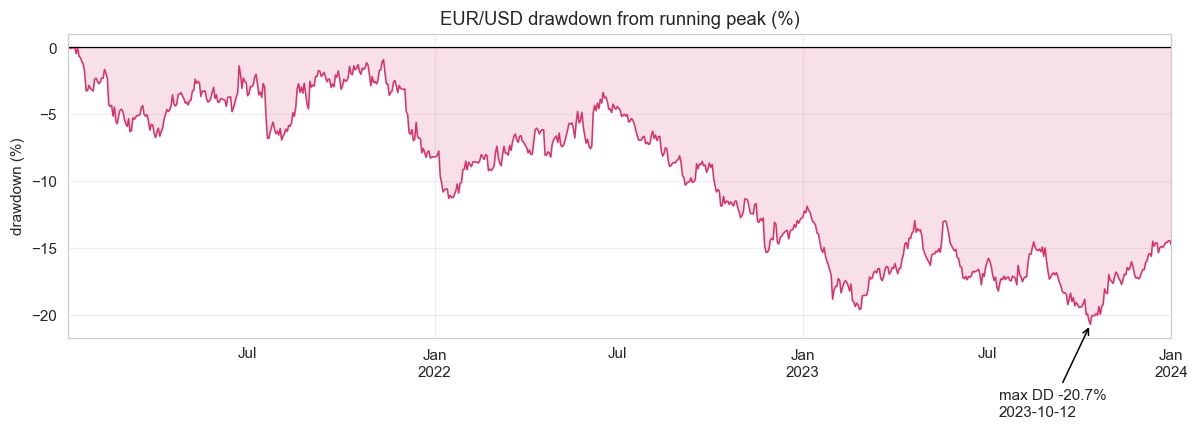

Max drawdown: -20.7% on 2023-10-12


In [9]:
# --- Drawdown: peak-to-trough decline from running peak ----------------------
level = eurusd["level"]
running_max = level.cummax()
drawdown = (level / running_max - 1.0) * 100

fig, ax = plt.subplots(figsize=(11, 4))
drawdown.plot(ax=ax, color="#d6336c", lw=1.0)
ax.fill_between(drawdown.index, 0, drawdown, color="#d6336c", alpha=0.15)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("drawdown (%)")
ax.set_title("EUR/USD drawdown from running peak (%)")
worst = drawdown.idxmin()
ax.annotate(f"max DD {drawdown.min():.1f}%\n{worst.date()}",
            xy=(worst, drawdown.min()), xytext=(-60, -60),
            textcoords="offset points", arrowprops=dict(arrowstyle="->", color="k"))
fig.tight_layout()
plt.show()
print(f"Max drawdown: {drawdown.min():.1f}% on {worst.date()}")


## 3 · Statistics to visualise FX series

Beyond a single pair, we visualise:
* **Rolling volatility** — how risk evolves through time (and across pairs).
* **Correlation matrix** — cross-currency co-movement / risk clustering.
* **Rolling correlation** — does the covariance regime shift over time?

> **Rule of thumb**: annualised vol is more comparable across FX pairs than
> raw daily std, because daily counts differ little between pairs (~252).
> For *crosses* involving JPY the scale differs — always compare on returns.


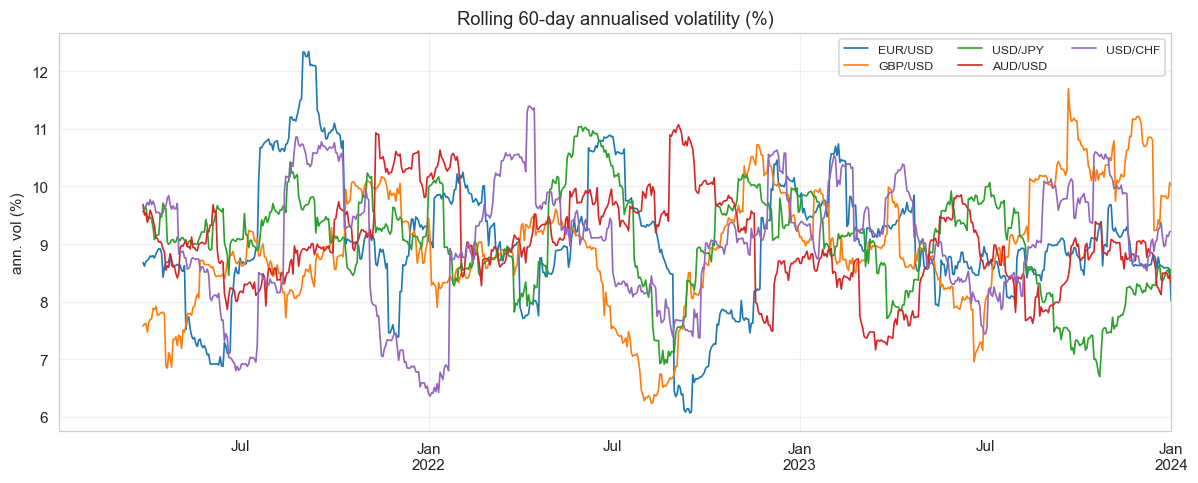

In [10]:
# --- Rolling annualised volatility across the majors -------------------------
win = 60
rolling_vol = ret.rolling(win).std() * np.sqrt(TRADING_DAYS_PER_YEAR) * 100

ax = rolling_vol.plot(figsize=(11, 4.5), lw=1.1, title=f"Rolling {win}-day annualised volatility (%)")
ax.set_ylabel("ann. vol (%)")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


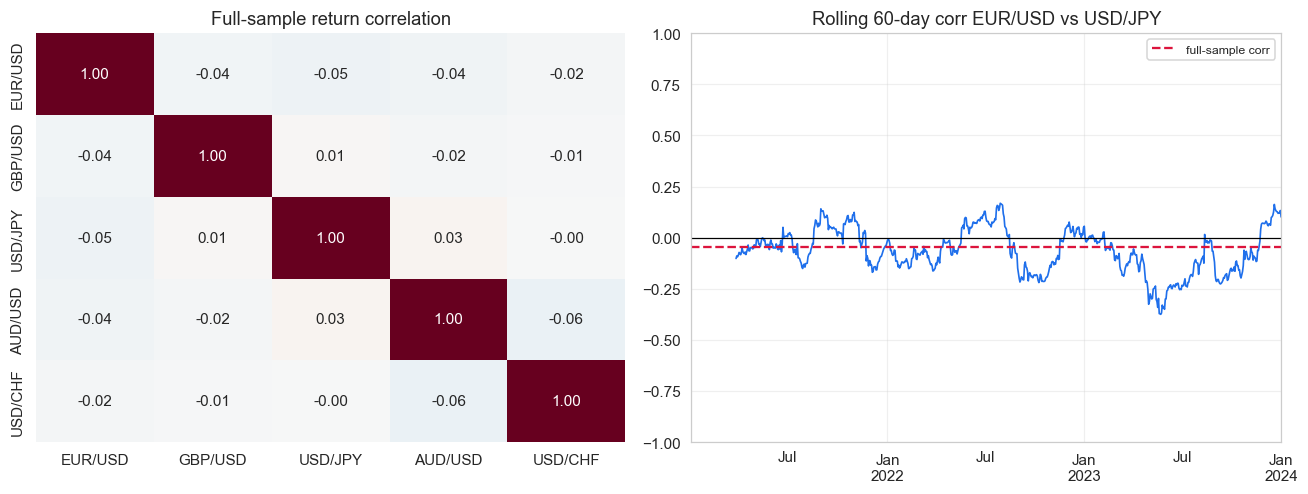

In [11]:
# --- Correlation heatmaps: full-sample vs. rolling ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.heatmap(ret.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Full-sample return correlation")

# Rolling correlation of EUR/USD vs USD/JPY — shows regime shifts
roll_corr = ret["EUR/USD"].rolling(win).corr(ret["USD/JPY"])
roll_corr.plot(ax=axes[1], color="#1f6feb", lw=1.1)
axes[1].axhline(ret["EUR/USD"].corr(ret["USD/JPY"]), color="crimson", ls="--",
                label="full-sample corr")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title(f"Rolling {win}-day corr EUR/USD vs USD/JPY")
axes[1].set_ylim(-1, 1)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## 4 · Cross-currency analysis

A **cross** is any FX pair that does not involve the US dollar, e.g. EUR/GBP,
EUR/JPY, AUD/NZD. The market quotes a small set of **base pairs** and *derives*
or *price-arbitrages* the rest. This section shows:

1. The **relationship between pairs** (which base builds which cross).
2. **Synthetic construction** of a cross from a triangle of available pairs.
3. **Triangular-consistency check** — the arbitrage condition.
4. What happens **when a rate is not available** (the whole point of crosses).


### The cross-currency triangle

A simple, powerful identity: if we know `EUR/USD` and `USD/JPY`, then

$$\text{EUR/JPY} = \text{EUR/USD} \times \text{USD/JPY}$$

i.e. $EUR/JPY = (EUR/USD)\cdot(USD/JPY)$. Similarly the *inverse* and any
intermediate pair from the closed triangle. Because FX is arbitraged, the
market keeps these identities (almost) exact.


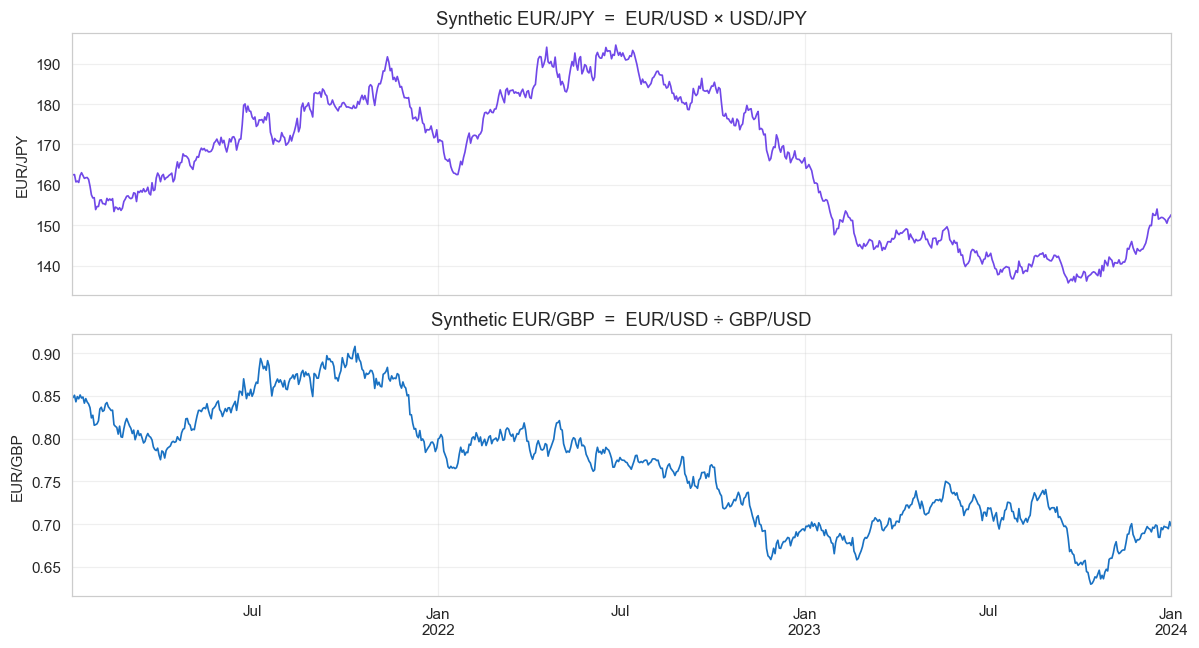

,EUR/JPY,EUR/GBP
2023-12-25,151.6141,0.6975
2023-12-26,151.2679,0.6965
2023-12-27,150.5054,0.6962
2023-12-28,151.5957,0.6946
2023-12-29,152.0051,0.7029
2024-01-01,152.5971,0.6978


In [12]:
# --- Reconstruct the majors cleanly -----------------------------------------
# We already simulated EUR/USD, USD/JPY, GBP/USD in `px`. Build a cross table
# combining an authenticated triangle that MUST be internally consistent.

eurusd_px   = px["EUR/USD"]
usdjpy_px   = px["USD/JPY"]
gbpusd_px   = px["GBP/USD"]

# --- Synthetic EUR/JPY from the triangle ------------------------------------
eurjpy_synth = eurusd_px * usdjpy_px          # EUR/USD * USD/JPY  == EUR/JPY

# --- EUR/GBP from the triangle ----------------------------------------------
eurgbp_synth = eurusd_px / gbpusd_px          # EUR/USD / GBP/USD  == EUR/GBP

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
eurjpy_synth.plot(ax=axes[0], color="#7048e8", lw=1.1, title="Synthetic EUR/JPY  =  EUR/USD × USD/JPY")
axes[0].set_ylabel("EUR/JPY")
eurgbp_synth.plot(ax=axes[1], color="#1971c2", lw=1.1, title="Synthetic EUR/GBP  =  EUR/USD ÷ GBP/USD")
axes[1].set_ylabel("EUR/GBP")
fig.tight_layout()
plt.show()

cross = pd.DataFrame({"EUR/JPY": eurjpy_synth, "EUR/GBP": eurgbp_synth})
cross.tail(6).round(4)


In [13]:
# --- Triangular consistency: reconstruct EUR/USD back from the cross --------
# EUR/USD == EUR/GBP * GBP/USD
eurusd_back = eurgbp_synth * gbpusd_px
max_gap = (eurusd_back / eurusd_px - 1.0).abs().max()

print("Max relative reconstruction gap (EUR/USD via EUR/GBP * GBP/USD):")
print(f"  {max_gap:.3e}")
print("-> Identities hold to machine precision" if max_gap < 1e-12 else "-> Check your arithmetic")

# Also show the inverse-pair relationship:
usdchf = px["USD/CHF"]


Max relative reconstruction gap (EUR/USD via EUR/GBP * GBP/USD):
  2.220e-16
-> Identities hold to machine precision


## 5 · Currency Swaps — why, how, and what drives them

For a **beginner** (and for anyone debugging an FX dataset), "swap" usually
means the **FX swap / swap points**: the gap between the *forward* and the
*spot* exchange rate. It is **not** a mysterious cost — it is interest-rate
arithmetic priced through time.

### Why do we need currency swaps?
1. **Hedging a timing mismatch** — you agree a trade *today* but need a *fixed*
   rate next month. A **forward** locks that rate, and the swap points are the
   "carry" you receive/pay for the privilege.
2. **Rolling open positions** — funding desks roll a spot position each night;
   the **overnight swap points** are the cost/benefit of that roll. That number
   is literally the "swap" a broker posts on your open FX position at 5pm.
3. **Funding in a foreign currency** — an FX swap lets you *borrow one currency
   while lending another*, locking the funding cost for a chosen tenor without
   taking spot risk.
4. **Pricing & arbitrage** — market-makers use the same formula to hedge one
   leg against the other and to price any missing maturity.

### How are swaps calculated?
Under **covered interest parity (CIP)**, with spot $S$, domestic rate $r_d$,
foreign rate $r_f$ and time $t$ (ACT/360):

$$F = S \cdot \frac{1 + r_d \cdot \frac{t}{360}}{1 + r_f \cdot \frac{t}{360}},
\qquad \text{Swap points} = F - S$$

* $r_d > r_f$  →  forward **above** spot  →  *forward premium* (**positive** swap)
* $r_d < r_f$  →  forward **below** spot  →  *forward discount* (**negative** swap)

**Swap = the price of the interest-rate differential, scaled by time.**


### Spot vs forward — names & conventions

Before computing anything, pin down the vocabulary:

* **Spot rate ($S$)** — the rate for *immediate* settlement. In EUR/USD that is
  **T+2** (two business days: the deal is agreed today, cash moves two days
  later). Conventions differ (USD/TRY and USD/BRL settle T+1, USD/CAD T+1).
* **Forward rate ($F$)** — the rate **agreed today** for a currency exchange at
  a *specified future date*. You lock $F$ now; what spot *actually* prints at
  that future date is irrelevant to your contract.
* **Swap points / forward points** — $F - S$, the small adjustment on top of
  spot. Traders quote forwards as *points on spot* because spot is volatile
  while the points are comparatively stable.

> **The single most important idea**: a forward is **not a prediction** of where
> spot will be. A **30-day forward is not** "we agree spot will be 1.0712 in a
> month". It is the rate at which you are *guaranteed* to exchange currencies in
> 30 days, no matter where spot goes. The market can offer this guarantee at
> almost no risk to you because it is **funded and hedged**, not forecast.

### What the different maturities mean

* **1M / 30-day forward** — settlement ~1 calendar month after spot: € settled
  vs \$ in ~30 days at today's locked rate.
* **3M / 90-day forward** — the workhorse tenor for the money-market curve.
* **6M, 1Y** — longer tenors used to hedge trade receivables, FDI, funding.
* **O/N (overnight) & T/N (tom-next)** — roll a *spot* settlement one day; these
  tiny swap points are what your broker posts as the nightly "swap" on an open
  position.

### Do we create a forward contract for every date?
No. The market quotes **standard tenors** (O/N, T/N, 1W, 1M, 2M, 3M, 6M, 9M,
1Y, …). A trade whose horizon does not match a standard tenor is a **"broken" or
"odd" date**, priced by **interpolating** the swap points between the two
neighbouring standard tenors — any date *can* be traded, it just costs slightly
more depth to price.

### What are tenors / tenor days?
A **tenor** is the time to maturity of the forward. Its **tenor days** is the
actual number of calendar/business days between the **spot settlement date** and
the **forward settlement date**, used with a day-count convention:

* **ACT/360** — most FX (EUR, USD, JPY, CHF, …): \#days / 360.
* **ACT/365** — GBP, and some other markets: \#days / 365.
* Settlement lands on a **valid business day** (the convention rolls month-end
  dates forward with "modified following").

The whole CIP pricing then reduces to: **swap points = spot × (rate difference
scaled by tenor days / year)**.


In [15]:
# --- Tenor settlement dates & tenor days (EUR/USD example) --------------------
def roll_to_bday(ts):
    while ts.dayofweek in (5, 6):            # land on a business day
        ts = ts + pd.Timedelta(days=1)
    return ts

spot_dt = pd.Timestamp("2024-01-02")         # a spot settlement date (deal before)
tenor_defs = [
    ("O/N", pd.DateOffset(days=1)),
    ("T/N", pd.DateOffset(days=1)),          # from spot: +1
    ("1W",  pd.DateOffset(days=7)),
    ("1M",  pd.DateOffset(months=1)),
    ("2M",  pd.DateOffset(months=2)),
    ("3M",  pd.DateOffset(months=3)),
    ("6M",  pd.DateOffset(months=6)),
    ("9M",  pd.DateOffset(months=9)),
    ("1Y",  pd.DateOffset(months=12)),
]

rows = []
for label, off in tenor_defs:
    sett = roll_to_bday(spot_dt + off)
    days = (sett - spot_dt).days
    rows.append({
        "tenor": label,
        "spot settlement": spot_dt.date(),
        "forward settlement": sett.date(),
        "tenor days (actual)": days,
        "days/360": round(days / 360, 4),
        "days/365": round(days / 365, 4),
    })
tenor_table = pd.DataFrame(rows)
tenor_table


,tenor,spot settlement,forward settlement,tenor days (actual),days/360,days/365
0,O/N,2024-01-02,2024-01-03,1,0.0028,0.0027
1,T/N,2024-01-02,2024-01-03,1,0.0028,0.0027
2,1W,2024-01-02,2024-01-09,7,0.0194,0.0192
3,1M,2024-01-02,2024-02-02,31,0.0861,0.0849
4,2M,2024-01-02,2024-03-04,62,0.1722,0.1699
5,3M,2024-01-02,2024-04-02,91,0.2528,0.2493
6,6M,2024-01-02,2024-07-02,182,0.5056,0.4986
7,9M,2024-01-02,2024-10-02,274,0.7611,0.7507
8,1Y,2024-01-02,2025-01-02,366,1.0167,1.0027


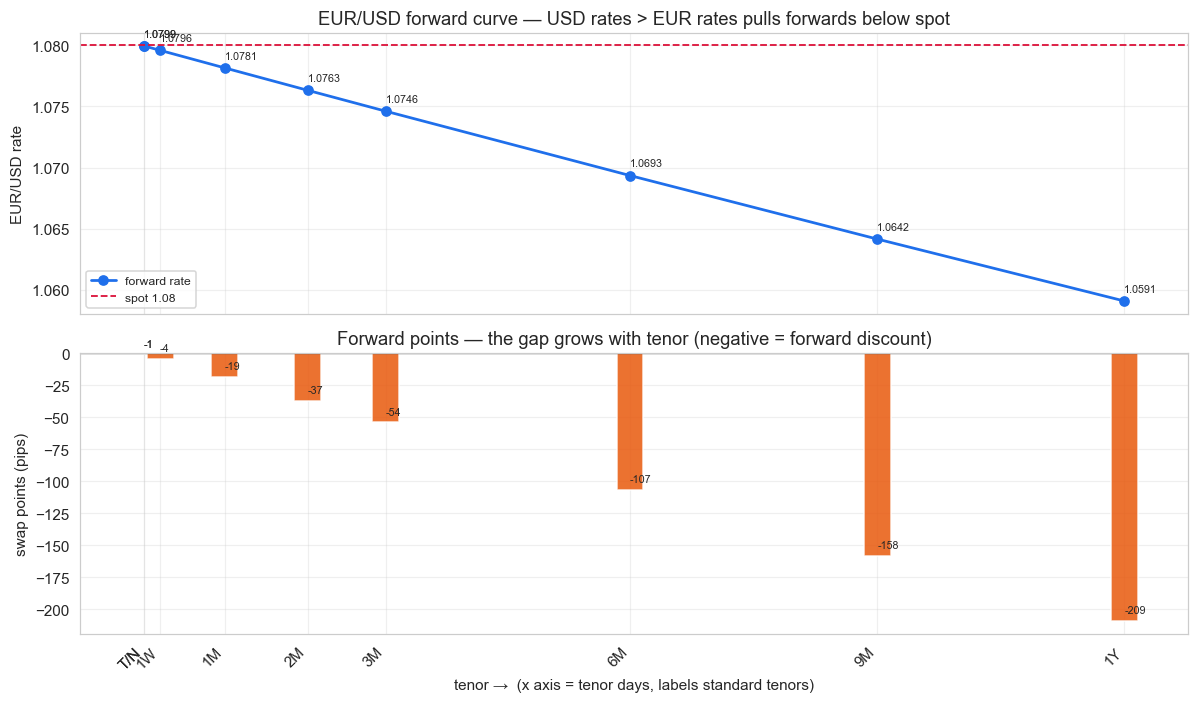

In [16]:
# --- Self-contained CIP forward helper (defined locally for this section) -----
def fwd_rate(spot, r_dom, r_for, days, basis=360):
    t = days / basis
    return spot * (1.0 + r_dom * t) / (1.0 + r_for * t)

# --- Forward-curve visualisation: rate AND swap points vs tenor days ----------
spot_eur = 1.08
r_eur = 0.03; r_usd = 0.05                     # USD rates > EUR => discount

std_days = tenor_table["tenor days (actual)"].to_numpy()
fwd_rates = fwd_rate(spot_eur, r_eur, r_usd, std_days)
fwd_pips  = (fwd_rates - spot_eur) * 1e4

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

# Top: forward rate vs spot
axes[0].plot(std_days, fwd_rates, marker="o", color="#1f6feb", lw=1.8, label="forward rate")
axes[0].axhline(spot_eur, color="crimson", ls="--", lw=1.2, label=f"spot {spot_eur}")
for d, r in zip(std_days, fwd_rates):
    axes[0].annotate(f"{r:.4f}", (d, r), textcoords="offset points", xytext=(0, 6), fontsize=7)
axes[0].set_ylabel("EUR/USD rate")
axes[0].set_title("EUR/USD forward curve — USD rates > EUR rates pulls forwards below spot")
axes[0].legend(fontsize=8)

# Bottom: swap/forward points in pips (the discount)
axes[1].bar(std_days, fwd_pips, color="#e8590c", alpha=0.85, width=10)
axes[1].axhline(0, color="k", lw=0.8)
for d, p in zip(std_days, fwd_pips):
    axes[1].annotate(f"{p:.0f}", (d, p), textcoords="offset points", xytext=(0, 5), fontsize=7)
axes[1].set_ylabel("swap points (pips)")
axes[1].set_title("Forward points — the gap grows with tenor (negative = forward discount)")

axes[1].set_xticks(std_days)
axes[1].set_xticklabels(tenor_table["tenor"], rotation=45, ha="right")
axes[1].set_xlabel("tenor →  (x axis = tenor days, labels standard tenors)")
fig.tight_layout(); plt.show()


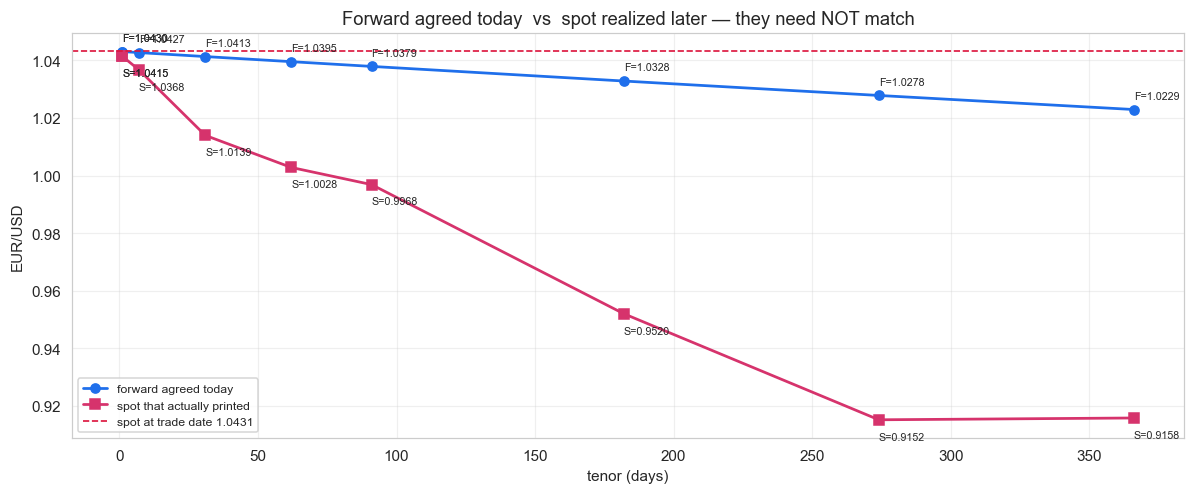

In [17]:
# --- The forward is NOT a forecast of future spot ------------------------------
# Pick a trade date mid-sample; price forwards today at its spot; then compare
# with the *actual* spot that later printed (from our simulated EUR/USD).
origin = pd.Timestamp("2022-07-01")
S0 = eurusd.loc[:origin]["level"].iloc[-1]

frow = []
for i, row in tenor_table.iterrows():
    days = row["tenor days (actual)"]
    fwd_t = fwd_rate(S0, r_eur, r_usd, days)
    sett = roll_to_bday(origin + pd.Timedelta(days=days))     # ~ settlement date
    realized = eurusd["level"].asof(sett)                     # actual spot printed
    frow.append({"tenor": row["tenor"], "tenor_days": days,
                 "forward_today": fwd_t, "realized_spot": realized})
frow = pd.DataFrame(frow)

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(frow["tenor_days"], frow["forward_today"], marker="o", color="#1f6feb",
        lw=1.8, label="forward agreed today")
ax.plot(frow["tenor_days"], frow["realized_spot"], marker="s", color="#d6336c",
        lw=1.8, label="spot that actually printed")
ax.axhline(S0, color="crimson", ls="--", lw=1.1, label=f"spot at trade date {S0:.4f}")
for _, r in frow.iterrows():
    ax.annotate(f"F={r['forward_today']:.4f}", (r["tenor_days"], r["forward_today"]),
                textcoords="offset points", xytext=(0, 7), fontsize=7)
    ax.annotate(f"S={r['realized_spot']:.4f}", (r["tenor_days"], r["realized_spot"]),
                textcoords="offset points", xytext=(0, -13), fontsize=7)
ax.set_xlabel("tenor (days)")
ax.set_ylabel("EUR/USD")
ax.set_title("Forward agreed today  vs  spot realized later — they need NOT match")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


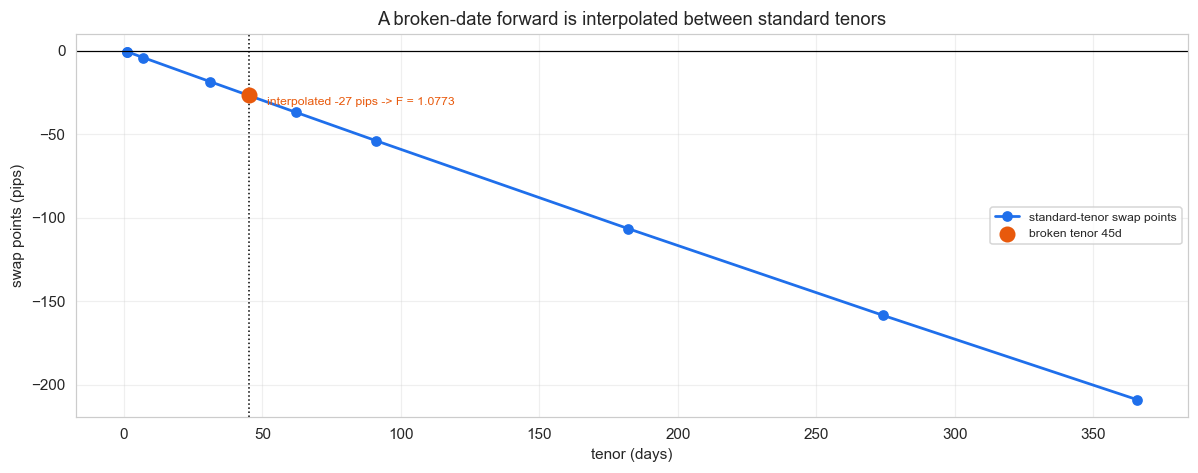

In [18]:
# --- Every date can be quoted: interpolating a "broken" tenor ------------------
# Only standard tenors have direct quotes. A 45-day trade is a *broken date*
# priced by linearly interpolating swap points between the surrounding tenors.

std_days = tenor_table["tenor days (actual)"].to_numpy()
std_pips = (fwd_rate(spot_eur, r_eur, r_usd, std_days) - spot_eur) * 1e4

broken_days = 45
broken_pts  = float(np.interp(broken_days, std_days, std_pips))     # pips
broken_fwd  = spot_eur + broken_pts / 1e4

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(std_days, std_pips, marker="o", color="#1f6feb", lw=1.8, label="standard-tenor swap points")
ax.axvline(broken_days, color="k", ls=":", lw=1.0)
ax.scatter([broken_days], [broken_pts], color="#e8590c", zorder=5, s=90,
           label=f"broken tenor {broken_days}d")
ax.annotate(f"interpolated {broken_pts:.0f} pips -> F = {broken_fwd:.4f}",
            (broken_days, broken_pts), textcoords="offset points",
            xytext=(12, -6), fontsize=8, color="#e8590c")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("tenor (days)"); ax.set_ylabel("swap points (pips)")
ax.set_title("A broken-date forward is interpolated between standard tenors")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


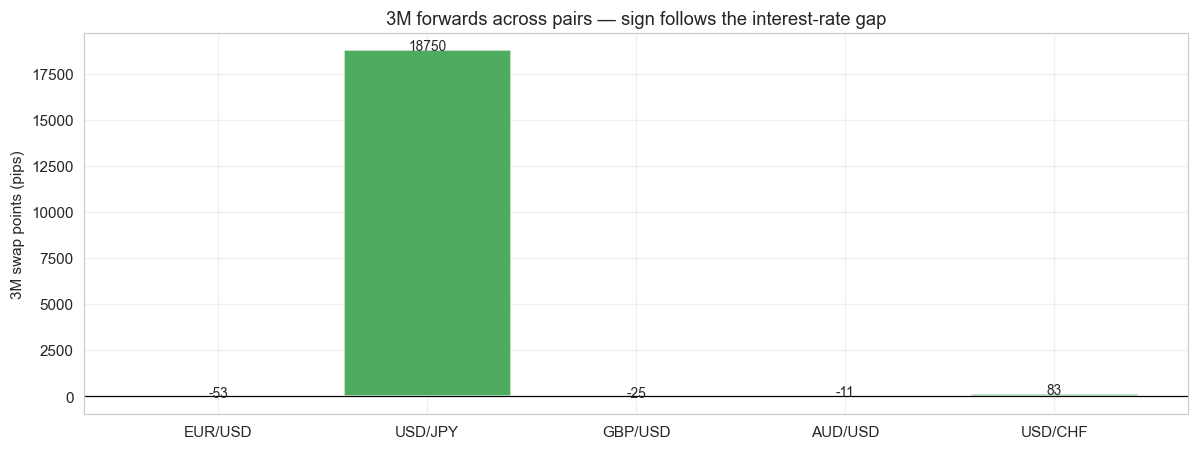

In [19]:
# --- Cross-currency: forwards exist for every pair -----------------------------
# The same CIP logic applies to any pair; sign & size follow that pair's rate gap.
pairs_fwd = {
    "EUR/USD": dict(spot=1.08,  rd=0.030, rf=0.050),   # USD > EUR  -> discount
    "USD/JPY": dict(spot=150.0, rd=0.050, rf=0.000),   # JPY ~ 0%   -> premium
    "GBP/USD": dict(spot=1.27,  rd=0.042, rf=0.050),   # USD > GBP  -> discount
    "AUD/USD": dict(spot=0.66,  rd=0.0435, rf=0.050),
    "USD/CHF": dict(spot=0.88,  rd=0.050, rf=0.012),
}
threeM = 90
cc = pd.DataFrame({
    name: {
        "3M forward": round(fwd_rate(c["spot"], c["rd"], c["rf"], threeM), 4),
        "3M swap pips": round((fwd_rate(c["spot"], c["rd"], c["rf"], threeM) - c["spot"]) * 1e4, 0),
        "annualised carry %": round((fwd_rate(c["spot"], c["rd"], c["rf"], threeM) / c["spot"] - 1) * 360 / threeM * 100, 2),
    }
    for name, c in pairs_fwd.items()
}).T
cc

fig, ax = plt.subplots(figsize=(11, 4.2))
names = list(pairs_fwd.keys())
pips = cc["3M swap pips"].astype(float).to_numpy()
bars = ax.bar(names, pips, color=["#d6336c" if p < 0 else "#2f9e44" for p in pips], alpha=0.85)
ax.axhline(0, color="k", lw=0.8)
for b, p in zip(bars, pips):
    ax.text(b.get_x() + b.get_width()/2, p + (2 if p >= 0 else -4), f"{p:.0f}",
            ha="center", fontsize=9)
ax.set_ylabel("3M swap points (pips)")
ax.set_title("3M forwards across pairs — sign follows the interest-rate gap")
plt.tight_layout(); plt.show()


In [20]:

def fx_swap_points(spot, r_dom, r_for, days, basis=360):
    """Covered interest parity -> (forward_rate, swap_points)."""
    t = days / basis
    fwd = spot * (1.0 + r_dom * t) / (1.0 + r_for * t)
    return fwd, (fwd - spot)

# --- EUR/USD worked example ------------------------------------------------
spot_eurusd = 1.08
r_eur = 0.0300          # EUR 3M money-market rate (3.0%)
r_usd = 0.0500          # USD 3M money-market rate (5.0%)
days_3m = 90

fwd_3m, swap_3m = fx_swap_points(spot_eurusd, r_eur, r_usd, days_3m)
print(f"EUR/USD spot        : {spot_eurusd:.4f}")
print(f"EUR/USD 3M forward  : {fwd_3m:.4f}")
print(f"3M swap points      : {swap_3m:.5f}  ({swap_3m * 1e4:.0f} pips)")
print(f"annualised premium  : {swap_3m / spot_eurusd * 360 / days_3m * 100:.2f}%")


EUR/USD spot        : 1.0800
EUR/USD 3M forward  : 1.0747
3M swap points      : -0.00533  (-53 pips)
annualised premium  : -1.98%


In [21]:
# --- Swap points across the tenor ladder ------------------------------------
maturities = [("1W", 7), ("1M", 30), ("3M", 90), ("6M", 180), ("1Y", 360)]

rows = []
for name, days in maturities:
    fwd, swap = fx_swap_points(spot_eurusd, r_eur, r_usd, days)
    rows.append({
        "tenor": name, "days": days, "forward": round(fwd, 4),
        "swap_pips": round(swap * 1e4, 1),
        "prem_ann_pct": round(swap / spot_eurusd * 360 / days * 100, 2),
    })
ladder = pd.DataFrame(rows).set_index("tenor")
ladder


,days,forward,swap_pips,prem_ann_pct
tenor,,,,
1W,7,1.0796,-4.2,-2.00
1M,30,1.0782,-17.9,-1.99
3M,90,1.0747,-53.3,-1.98
6M,180,1.0695,-105.4,-1.95
1Y,360,1.0594,-205.7,-1.90


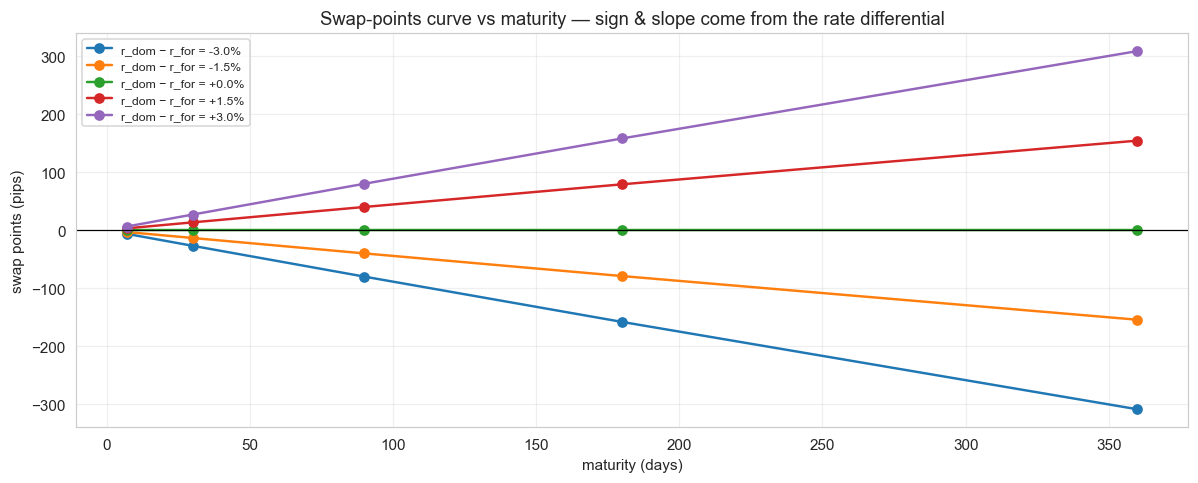

In [22]:
# --- Visualisation 1: swap-points curve vs maturity for several differentials
base_r_for = 0.05                                  # fix foreign (USD) at 5%
diffs = [-0.03, -0.015, 0.0, 0.015, 0.03]          # r_dom - r_for variations

fig, ax = plt.subplots(figsize=(11, 4.5))
for diff in diffs:
    r_dom = base_r_for + diff
    pts = [fx_swap_points(spot_eurusd, r_dom, base_r_for, d)[1] * 1e4 for _, d in maturities]
    ax.plot([d for _, d in maturities], pts, marker="o", lw=1.6,
            label=f"r_dom − r_for = {diff*100:+.1f}%")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("maturity (days)")
ax.set_ylabel("swap points (pips)")
ax.set_title("Swap-points curve vs maturity — sign & slope come from the rate differential")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


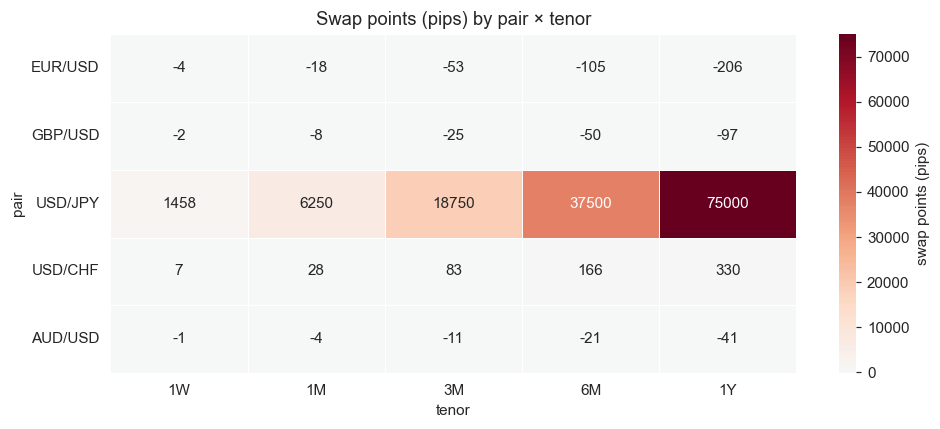

In [23]:
# --- Visualisation 2: swap-points heatmap across pairs and tenors ------------
pairs = {
    "EUR/USD": dict(spot=1.08,  rd=0.030, rf=0.050),   # USD > EUR  → discount
    "GBP/USD": dict(spot=1.27,  rd=0.042, rf=0.050),   # USD > GBP  → discount
    "USD/JPY": dict(spot=150.0, rd=0.050, rf=0.000),   # JPY ~ 0    → premium
    "USD/CHF": dict(spot=0.88,  rd=0.050, rf=0.012),
    "AUD/USD": dict(spot=0.66,  rd=0.0435, rf=0.050),
}
grid = pd.DataFrame({
    name: {mn: fx_swap_points(cfg["spot"], cfg["rd"], cfg["rf"], d)[1] * 1e4
           for mn, d in maturities}
    for name, cfg in pairs.items()
}).T
grid.columns = [mn for mn, _ in maturities]

plt.figure(figsize=(9, 4))
sns.heatmap(grid, annot=True, fmt=".0f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"label": "swap points (pips)"})
plt.title("Swap points (pips) by pair × tenor")
plt.ylabel("pair"); plt.xlabel("tenor")
plt.tight_layout(); plt.show()


### What drives swap prices?
* **Interest-rate differential** (policy / money-market rates) — *first-order*:
  a widening gap moves swap points in the same direction.
* **Time to maturity** — longer tenors compound the differential, so the curve
  typically steepens in the direction of the differential.
* **Expected rate changes** — it is the *shape* of the money-market curve
  (term structure of the short rate), not just today's level.
* **Funding / liquidity pressure** — quarter-end, stress, or a funding squeeze
  widen **cross-currency basis**, pushing real swap points away from pure CIP.
* **Volatility & risk** — in a crisis, boxes shift and basis blows out; swap
  points embed a premium for balance-sheet / counterparty constraints.

The next visualisation shows the *time-series* driver: as a central bank
tightens (raising $r_d$) relative to the foreign rate, the implied swap points
flip from negative to positive — exactly what you would see in live data.


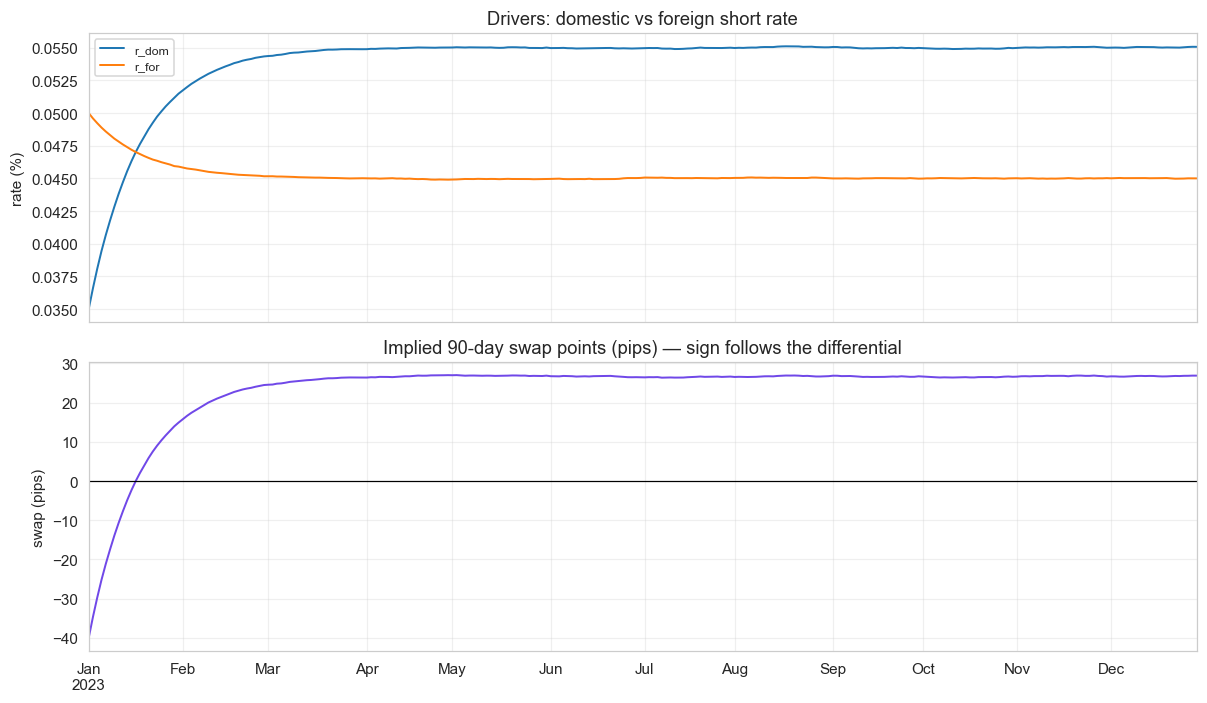

swap over sample: -40.0 -> +26.9 pips


In [24]:
# --- Visualisation 3: a time-varying differential moves swap points -----------
rng = np.random.default_rng(2024)
n = 260
idx = pd.bdate_range("2023-01-02", periods=n)
horizon = 90  # 3M tenor

def rate_path(start, target, vol, kappa=20.0):
    r = np.zeros(n); r[0] = start
    for i in range(1, n):
        r[i] = r[i-1] + kappa * (target - r[i-1]) * (1 / 252) + rng.normal(0, vol / 252)
    return r

r_dom = rate_path(0.035, 0.055, 0.004)   # domestic central bank tightening
r_for = rate_path(0.050, 0.045, 0.003)   # foreign easing slightly

swap_ts = np.array([fx_swap_points(1.08, rd, rf, horizon)[1] * 1e4
                    for rd, rf in zip(r_dom, r_for)])
df_swap = pd.DataFrame({"r_dom": r_dom, "r_for": r_for, "swap_pips": swap_ts}, index=idx)

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
df_swap[["r_dom", "r_for"]].plot(ax=axes[0], lw=1.3,
                                 title="Drivers: domestic vs foreign short rate")
axes[0].set_ylabel("rate (%)"); axes[0].legend(fontsize=8)
df_swap["swap_pips"].plot(ax=axes[1], color="#7048e8", lw=1.3,
                          title=f"Implied {horizon}-day swap points (pips) — sign follows the differential")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_ylabel("swap (pips)")
fig.tight_layout(); plt.show()

print(f"swap over sample: {df_swap['swap_pips'].iloc[0]:+.1f} -> {df_swap['swap_pips'].iloc[-1]:+.1f} pips")


## 6 · When a rate is **not available**

Real FX datasets are rarely tidy:
* A **bank holiday** in one country closes the local session, so one pair
  misses a day while another prints.
* A **thinly-traded cross** may have **NaN** rows for hours or days.
* A **vendor backfills** a series starting later than others → leading NaNs.

The solution strategy is the same arithmetic we already use, plus sensible
**calendar alignment** and **filling**. We cover:

1. **Reindexing** to a full business-day calendar.
2. **Forward-filling** (`ffill`) — "last known rate".
3. **Interpolation**, and comparison of the two.
4. **Synthetic replacement** — when the pair itself is missing, build it from
   the triangle (the robust fix for whole-series unavailability).


In [27]:
# --- Build a "ragged" dataset: USD/CHF missing several days -----------------
# Simulate a market that is closed on a handful of dates (e.g. Swiss holiday).
rng = np.random.default_rng(7)
missing_days = pd.to_datetime(rng.choice(px.index, size=25, replace=False)).sort_values()

ragged = px["USD/CHF"].copy()
ragged.loc[missing_days] = np.nan
print("Rows with missing USD/CHF:", ragged.isna().sum(), "/", len(ragged))

# --- Strategy 1: reindex to the full business calendar ----------------------
full_calendar = pd.bdate_range(px.index.min(), px.index.max())
reindexed = ragged.reindex(full_calendar)
print("Reindexed rows:", len(reindexed), "| NaNs:", reindexed.isna().sum())

# --- Strategy 2: forward-fill  (carry last known rate) ----------------------
ffilled = reindexed.ffill()
# --- Strategy 3: linear interpolation ---------------------------------------
interped = reindexed.interpolate(method="linear")

errors = pd.DataFrame(
    {
        "ffill (vs true)":       [np.abs(ffilled  - px["USD/CHF"].reindex(full_calendar)).mean()],
        "interpolate (vs true)": [np.abs(interped - px["USD/CHF"].reindex(full_calendar)).mean()],
    }
)
errors.round(6)


Rows with missing USD/CHF: 25 / 781
Reindexed rows: 781 | NaNs: 25


,ffill (vs true),interpolate (vs true)
0,0.000126,0.000066


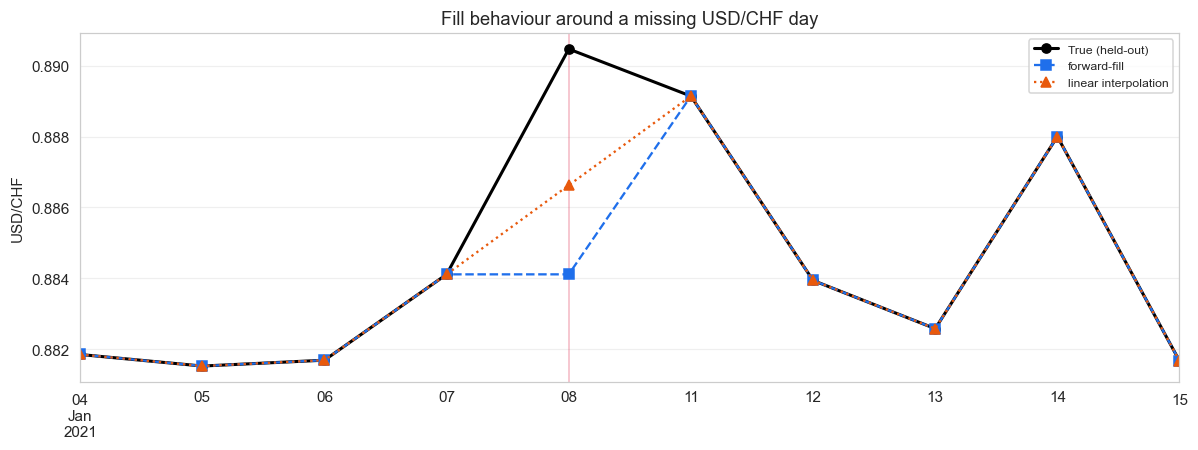

In [28]:
# --- Visualise what each fill does around a missing patch -------------------
window_days = missing_days[:1].values[0] - pd.Timedelta(days=8)
window_end  = missing_days[:1].values[0] + pd.Timedelta(days=8)
win = (reindexed.index >= window_days) & (reindexed.index <= window_end)

true_ = px["USD/CHF"].reindex(full_calendar)
ax = true_[win].plot(figsize=(11, 4.2), color="k", lw=2, label="True (held-out)", marker="o")
ffilled[win].plot(ax=ax, color="#1f6feb", ls="--", marker="s", lw=1.5, label="forward-fill")
interped[win].plot(ax=ax, color="#e8590c", ls=":", marker="^", lw=1.5, label="linear interpolation")
ax.axvspan(missing_days[0], missing_days[0], color="crimson", alpha=0.3)
ax.set_title("Fill behaviour around a missing USD/CHF day")
ax.set_ylabel("USD/CHF")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [29]:
# --- Returns computed on raw vs filled --------------------------------------
raw_ret   = np.log(px["USD/CHF"]).diff()
fill_ret  = np.log(ffilled).diff().dropna()

comparison = pd.DataFrame({
    "raw (dropna)": describe_fx(raw_ret.dropna()),
    "after ffill":  describe_fx(fill_ret),
}).T
comparison[["annualized_vol", "skew", "excess_kurtosis"]].round(4)


,annualized_vol,skew,excess_kurtosis
raw (dropna),0.0903,-0.3285,2.9460
after ffill,0.0907,-0.3364,2.9589


> **Why ffill beats nothing**: with forward-fill the return on the fill day is
> **0%**, which understates true volatility but keeps the series **aligned** and
> avoids spurious zero-length gaps. If the "missing" pattern is systematic
> rather than rare, prefer **synthetic construction** from the triangle —
> that respects the *economic* relationship instead of projecting *stale* data.


In [30]:
# --- Imply the third leg of a triangle when a cross is unavailable -------------
# Triangle identities:  EUR/CHF = EUR/USD * USD/CHF
#                       USD/CHF = (1 / EUR/USD) * EUR/CHF
eurchf = eurusd_px * usdchf.reindex(eurusd_px.index)      # consistent EUR/CHF leg

# If USD/CHF were NOT quoted, rebuild it from EUR/USD and the EUR/CHF leg:
usdchf_implied = (1.0 / eurusd_px) * eurchf

aligned = pd.concat([usdchf, usdchf_implied], axis=1, join="inner").dropna()
gap = (aligned.iloc[:, 1] / aligned.iloc[:, 0] - 1.0).abs()
print("USD/CHF implied-from-triangle vs quoted:")
print("  max |relative gap| = %.3e" % gap.max())
print("  corr(daily rets)   = %.6f"
      % aligned.iloc[:, 0].pct_change().corr(aligned.iloc[:, 1].pct_change()))
print("-> a consistent triangle reproduces the leg to machine precision")
print()
print("Caution: the cross is only as good as its inputs. If the two legs come from")
print("un-arbitraged, independent sources, the implied cross will visibly drift.")


USD/CHF implied-from-triangle vs quoted:
  max |relative gap| = 2.220e-16
  corr(daily rets)   = 1.000000
-> a consistent triangle reproduces the leg to machine precision

Caution: the cross is only as good as its inputs. If the two legs come from
un-arbitraged, independent sources, the implied cross will visibly drift.


## 7 · Wrap-up & takeaways

* **Analyse returns, not levels.** FX levels are arbitrary scales; the
  stationary, cross-comparable object is the (log) return.
* **Expect fat tails & vol clustering.** Squared-return ACF >> return ACF is the
  GARCH fingerprint; summarise risk with **annualised vol**.
* **Crosses are arithmetic.** Any pair can be synthesised from a triangle of
  quoted majors, so missing or unavailable rates can be **reconstructed**.
* **Align before you fill.** Reindex to a business calendar first; prefer
  forward-fill for rare gaps and triangle-based synthetic reconstruction for
  systematic absence.
* **Watch the regime.** Correlations and volatilities are **time-varying** —
  a full-sample number can hide a structural shift (see the rolling chart).
* **Swaps = the rate differential priced in time.** Forward/swap points come
  from CIP, so the swap curve is a direct read on policy-rate expectations and
  cross-currency funding stress — pair it with spot EDA for the full picture.
